# **Comparative Analysis of Literary Translations in the Odyssey: Zipf's Law in Depth**

This is a comparative Zipf's Law analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. Zipf's Law Analysis

1. 

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [1]:
#--------------------------------------------------------------
#### Other libraries
#--------------------------------------------------------------
import sys
import os

import ast
from collections import Counter

import re
import nltk

#### Pandas set-up
import numpy as np
import pandas as pd

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

import scipy.stats as stats
from itertools import combinations

In [2]:
# ----------------------------------------------------------------------
# Visualization
# ----------------------------------------------------------------------

sys.path.append('/Users/debr/English-Homer/functions') 
import matplotlib.pyplot as plt
import seaborn as sns

import e_chroma as chroma # My Vizualization library
import e_plots as oz      # My custom plots library
import e_pandisplay as pan# My pandas display options

import e_nlp_ody as e     # Import my nlp functions

import warnings           # Nononsense provision
warnings.filterwarnings('ignore')


* Got some chroma in your soma, Oma!
	 »----> use chroma.save_figure(fig, 'my_plot')
Default output path: ./Homer_xplots/

* OZ is behind the curtain!
	 »----> use oz.<func>
	 »----> also, oz goes chroma (for styling)!

* Pan is taking over
	 »----> use pan.<func>
✓ Pandas display reset to pandisplay defaults

* The editor is in the house!
	 »----> use e.<func> e.g. nlp = e.NLPPipeline(language='english')

Stopwords customized:
  Added: {'ten', 'eight', 'seven', 'four', "'and", 'three', 'n', 'five', 'two', "'", 'one', 'six', 'nine'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {',\n        "\'",\n        ', '\\', '-', "'", '…', '—'}
  Punctuation to be removed: !"#$%&'()*+,,
        "'",
        -./:;<=>?@[\]^_`{|}~—…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# ----------------------------------------------------------------------
# File management
# ----------------------------------------------------------------------

# TO UPDATE
nb_id = "Zipf_Six_Mo-03_31_25"

output_path = f"./{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_path_plots = f"./{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)
chroma.set_output_path(output_path_plots)

Output path set to: ././Zipf_Six_Mo-03_31_25//Zipf_Six_Mo-03_31_25_plots/


In [4]:
# ----------------------------------------------------------------------
# Odysseys
# ----------------------------------------------------------------------

translators = ['AT_Murray', 'Fitzgerald', 'Lattimore', 'Fagles', 'Wilson', 'Green']

dfs = []

for odyssey in translators:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df['translator'] = pd.Categorical(df['author'])
df["book_num"] = pd.Categorical(df["book_num"])
df = df[['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
e.check_df(df)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens'], dtype='object') 

* Shape: (144, 6) 

* Total memory in MB: 3.490719


In [5]:
df.sample(2, random_state=4)

,translator,book_num,text,tokens,num_words,num_tokens
128,Green,9,"[Then resourceful Odysseus responded to him, saying:\n, “Alkinoos, lord, most distinguished among all peoples,\n, it is indeed a good thing to listen to such a minstrel\n, as this man is, who rese...","[resourceful, odysseus, responded, saying, alkinoos, lord, distinguished, among, peoples, indeed, good, thing, listen, minstrel, man, resembles, gods, singing, say, greater, fulfillment, pleasure,...",5950,2786
5,AT_Murray,6,"[So here Odysseus slept, overcome by sleep and\n, toil; but Athena went off to the demos and city of\n, the Phaeacians - a people who used to live in the fair town of Hypereia, near\n, the lawless...","[odysseus, slept, overcome, sleep, toil, athena, went, demos, city, phaeacians, people, used, live, fair, town, hypereia, near, lawless, cyclopes, cyclopes, stronger, force, plundered, king, nausi...",3470,1492


#### 2. **The translators**

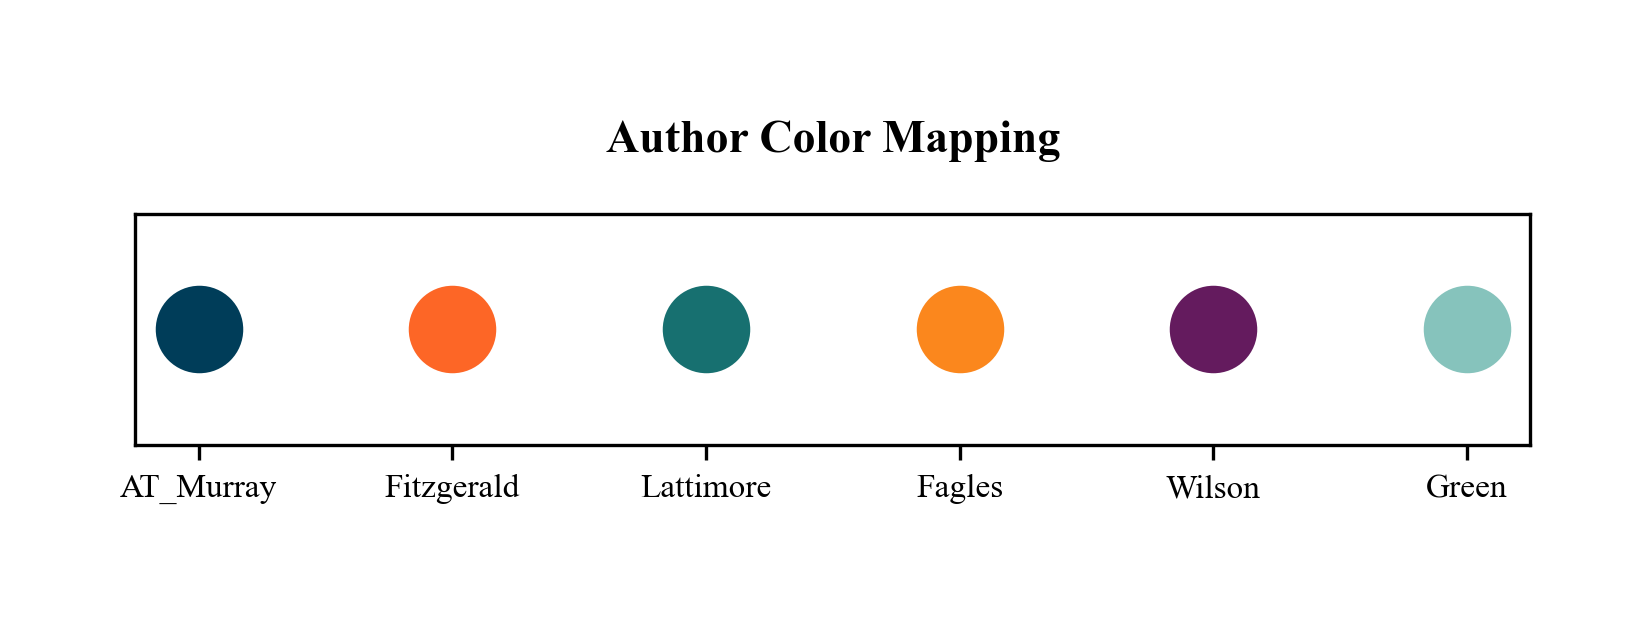

In [6]:
# Color mapping authors
palette = {author: color for author, 
           color in zip(translators, chroma.color_palette.values())}

plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=400)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

________________________________
## **II. Zipf’s Law Analysis**

### **What and why:** 

Zipf’s Law states that in a large text corpus, the frequency of a word is inversely proportional to its rank in the frequency table. This metric is relevant in comparing translations because it reveals how each translator balances **common vs. rare words**, shedding light on **lexical richness and stylistic choices**. This experiment provides empirical insight into whether a translator’s lexical distribution align with universal linguistic principles.


### **Implications for Translation Studies**

**a) natural linguistic flow:** Strong Zipfian adherence suggests that translators maintain natural language patterns, balancing high-frequency function words with low-frequency content words.  

**b.1) Poetic stylization:** Deviations may indicate differences in lexical richness, syntactic choices, or stylistic adaptation in translation.  
**b.2) Philological fidelity:** 'Stylistic' shifts can also point out to genre requirements that, in the case of epic oral poetry, demand disticnt repetitive and formulaic patterns, epithets, etc.



### **Implementation** 

Zipf’s Law states that in any natural language corpus, *the frequency of a word is inversely proportional to its rank:* 


$$ f \propto \frac{1}{r} $$

Where:
* f = frequency of the word
* r = rank of the word (1st most frequent, 2nd most frequent, etc.)

Procedure:
1. Compute word frequencies for each translation.  
2. Rank words from most to least frequent.  
3. Plot word frequency vs. rank on a log-log scale. 


In [7]:
#--------------------------------------------------------------
# Zipf's Law
#--------------------------------------------------------------

# Step 1: Flatten tokens and count word frequencies for each translator
freq_dict = {
    translator: Counter(
        token for tokens in df[df["translator"] == translator]["tokens"] for token in tokens
    )
    for translator in translators
}

# Step 2: Convert word frequencies into sorted DataFrames with rank
df_word_freq_rank_dict = {
    translator: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for translator, freq in freq_dict.items()
}

# Example: Accessing a specific translator’s Zipf DataFrame
df_word_freq_rank_dict["AT_Murray"].tail(15).T  # View the top-ranked words for AT_Murray

,3890,3891,3892,3893,3895,3897,3898,3903,3904,3905,3906,3907,3909,3910,6320
word,depends,noiselessly,threes,withies,ensconced,udders,backs,wont,mob,flowery,mead,bubbling,lag,nogood,parties
frequency,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
rank,6307.00,6308.00,6309.00,6310.00,6311.00,6312.00,6313.00,6314.00,6315.00,6316.00,6317.00,6318.00,6319.00,6320.00,6321.00


In [8]:
# Print total number of tokens per translator
for translator in translators:
    total_tokens = sum(freq_dict[translator].values())
    print(f"{translator}: {total_tokens} tokens")

AT_Murray: 51047 tokens
Fitzgerald: 53418 tokens
Lattimore: 61716 tokens
Fagles: 61974 tokens
Wilson: 47705 tokens
Green: 59202 tokens


In [9]:
# Compute min and max ranks across all translators
min_rank = min(df["rank"].min() for df in df_word_freq_rank_dict.values())
max_rank = max(df["rank"].max() for df in df_word_freq_rank_dict.values())

# Compute min and max frequencies across all translators
min_freq = min(df["frequency"].min() for df in df_word_freq_rank_dict.values())
max_freq = max(df["frequency"].max() for df in df_word_freq_rank_dict.values())

print(f"Rank range: from the {min_rank}st to {max_rank}th less freq word (unique set and stopwords removed).")
print(f"Frequency range: low words in rank appear at least {min_freq} time and the most freq has {max_freq} instances.")

Rank range: from the 1.0st to 8540.0th less freq word (unique set and stopwords removed).
Frequency range: low words in rank appear at least 1 time and the most freq has 718 instances.


Figure saved as ././Zipf_Six_Mo-03_31_25//Zipf_Six_Mo-03_31_25_plots/Log-Log-Zipf_Six_Mo-03_31_25.png at 400 DPI


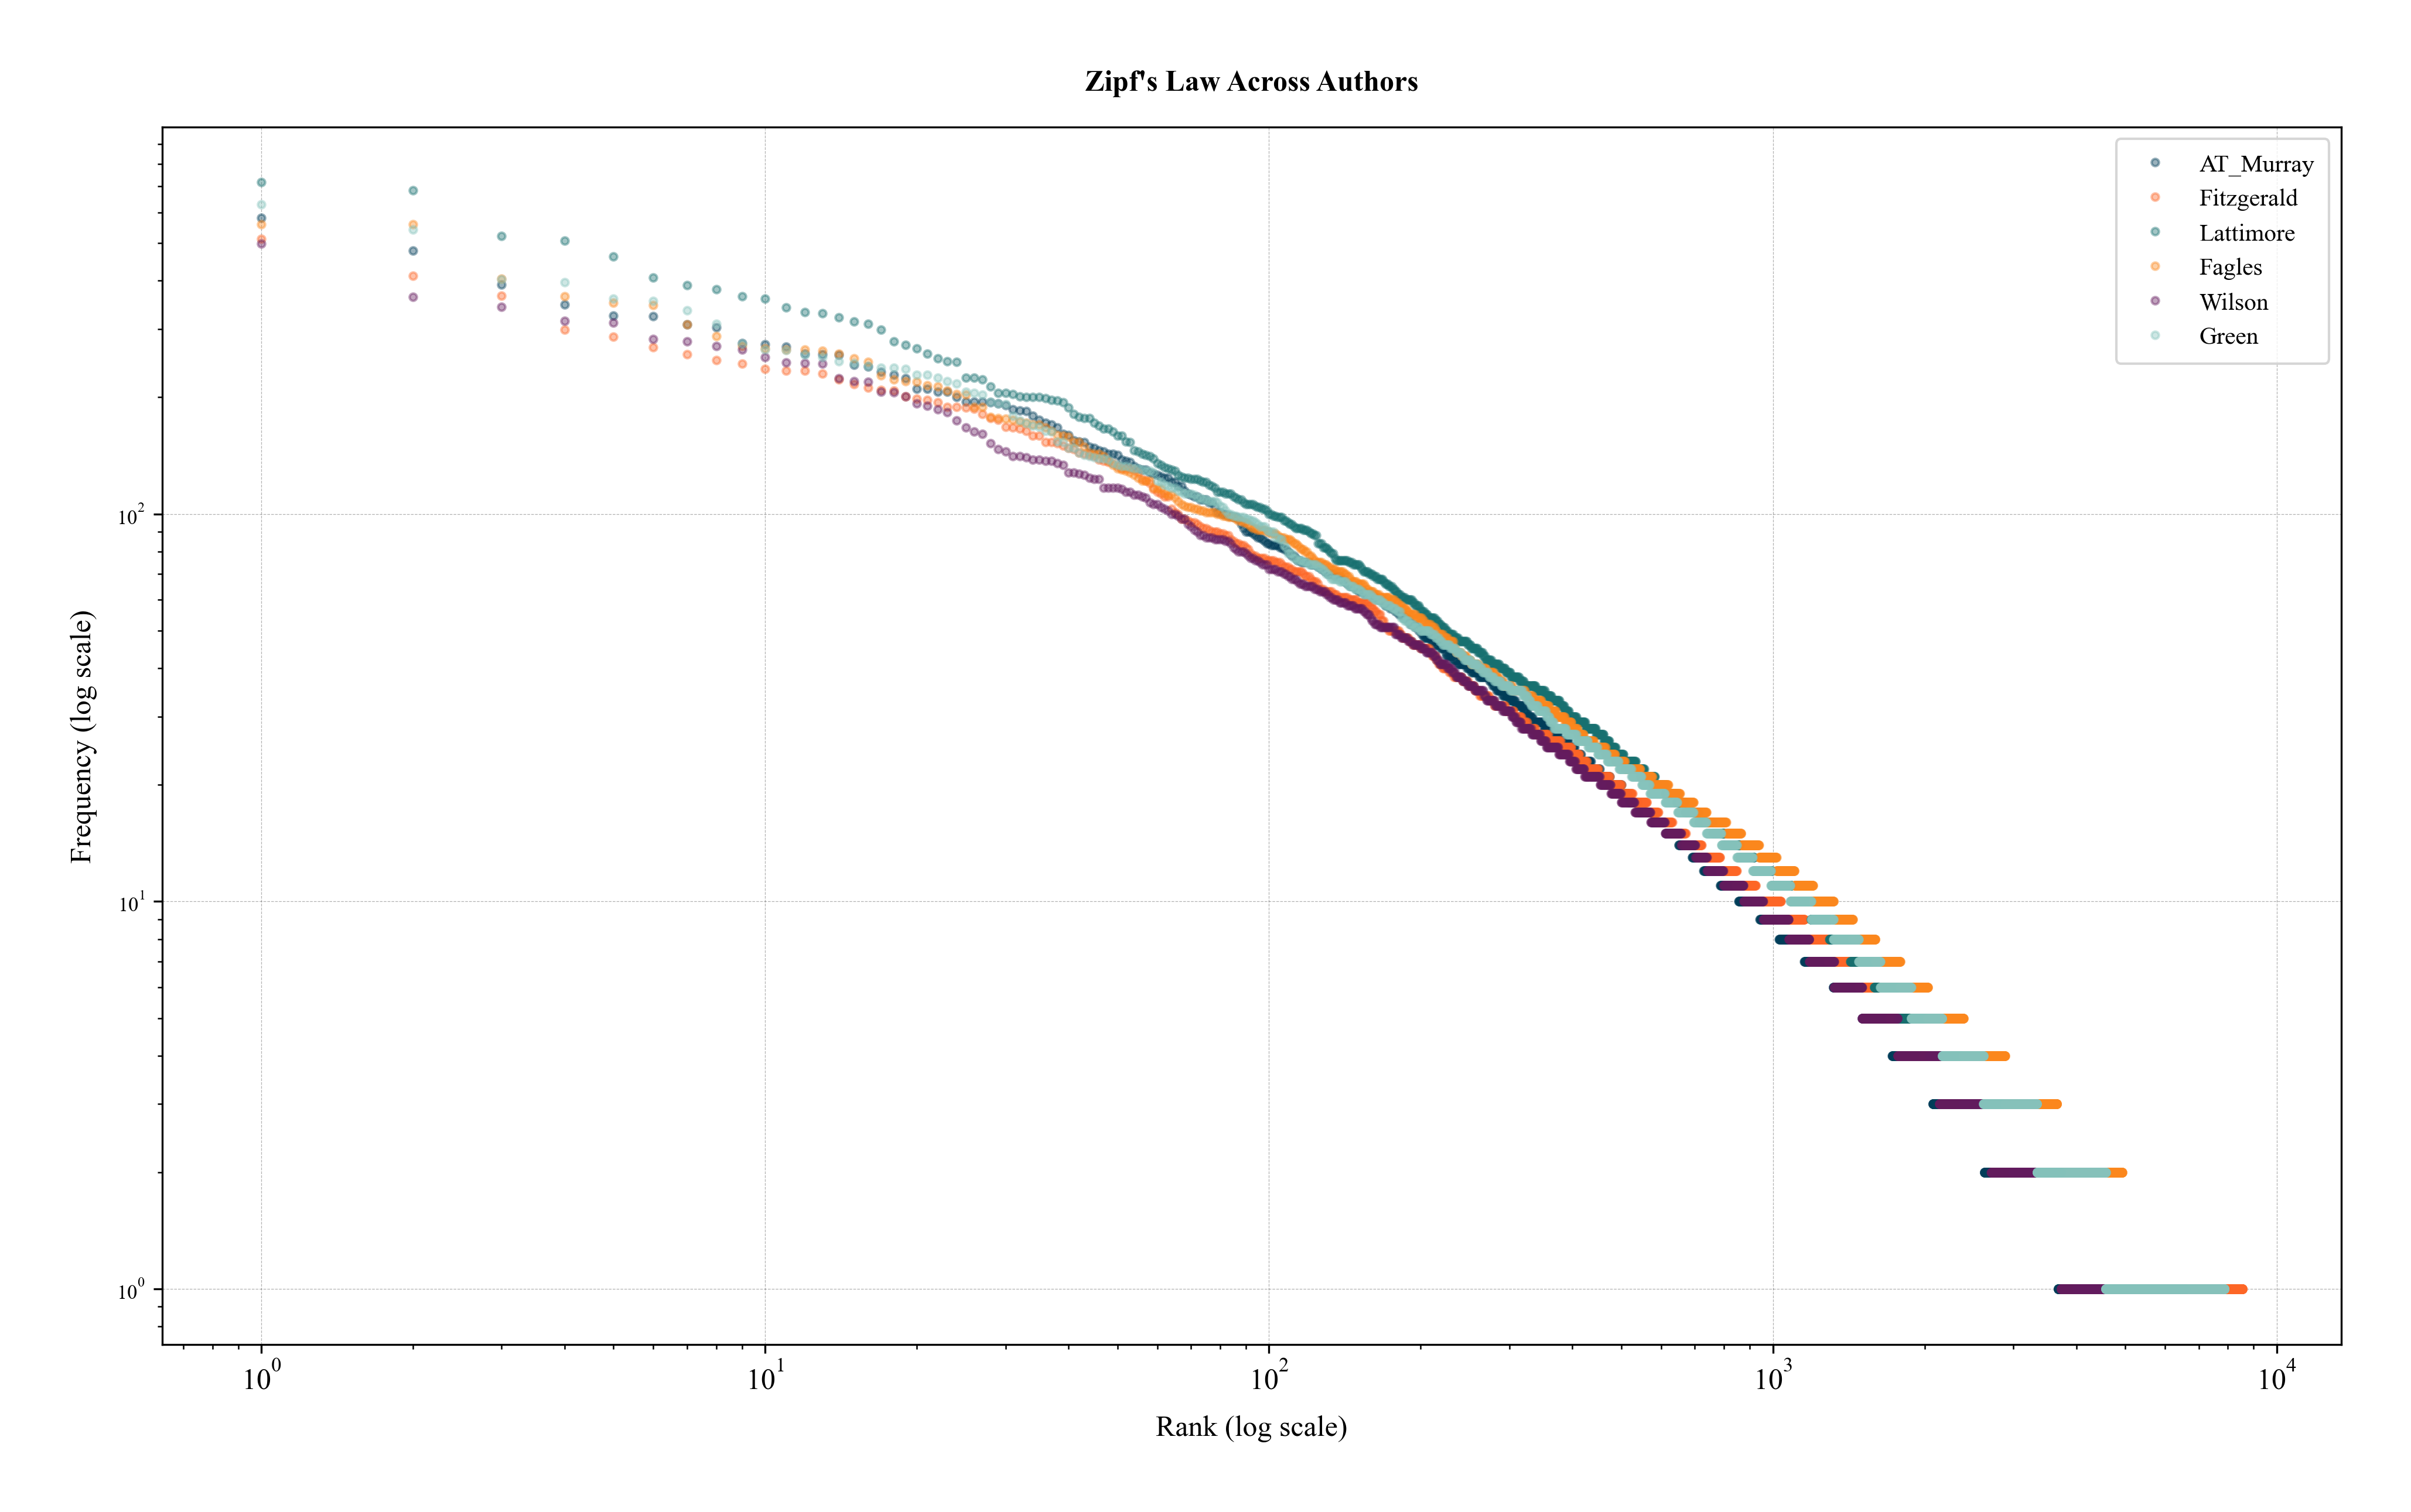

In [10]:
# Step 3: Plot Zipf's Law
def plot_zipfs_law(df_word_freq_rank_dict):
    fig, ax = plt.subplots()  # Create a figure and an axes object
    for author, df_zipf in df_word_freq_rank_dict.items():
        ax.loglog(df_zipf["rank"], df_zipf["frequency"], 
                   label=author, marker=".", linestyle="None", alpha=0.4)
    
    ax.set_xlabel("Rank (log scale)")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_title("Zipf's Law Across Authors")
    ax.legend()
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    
    return fig  # Return the figure object

fig = plot_zipfs_law(df_word_freq_rank_dict)

chroma.save_figure(fig, f"Log-Log-{nb_id}.png")

Figure saved as ././Zipf_Six_Mo-03_31_25//Zipf_Six_Mo-03_31_25_plots/Log-Log-Fit-Zipf_Six_Mo-03_31_25.png at 400 DPI


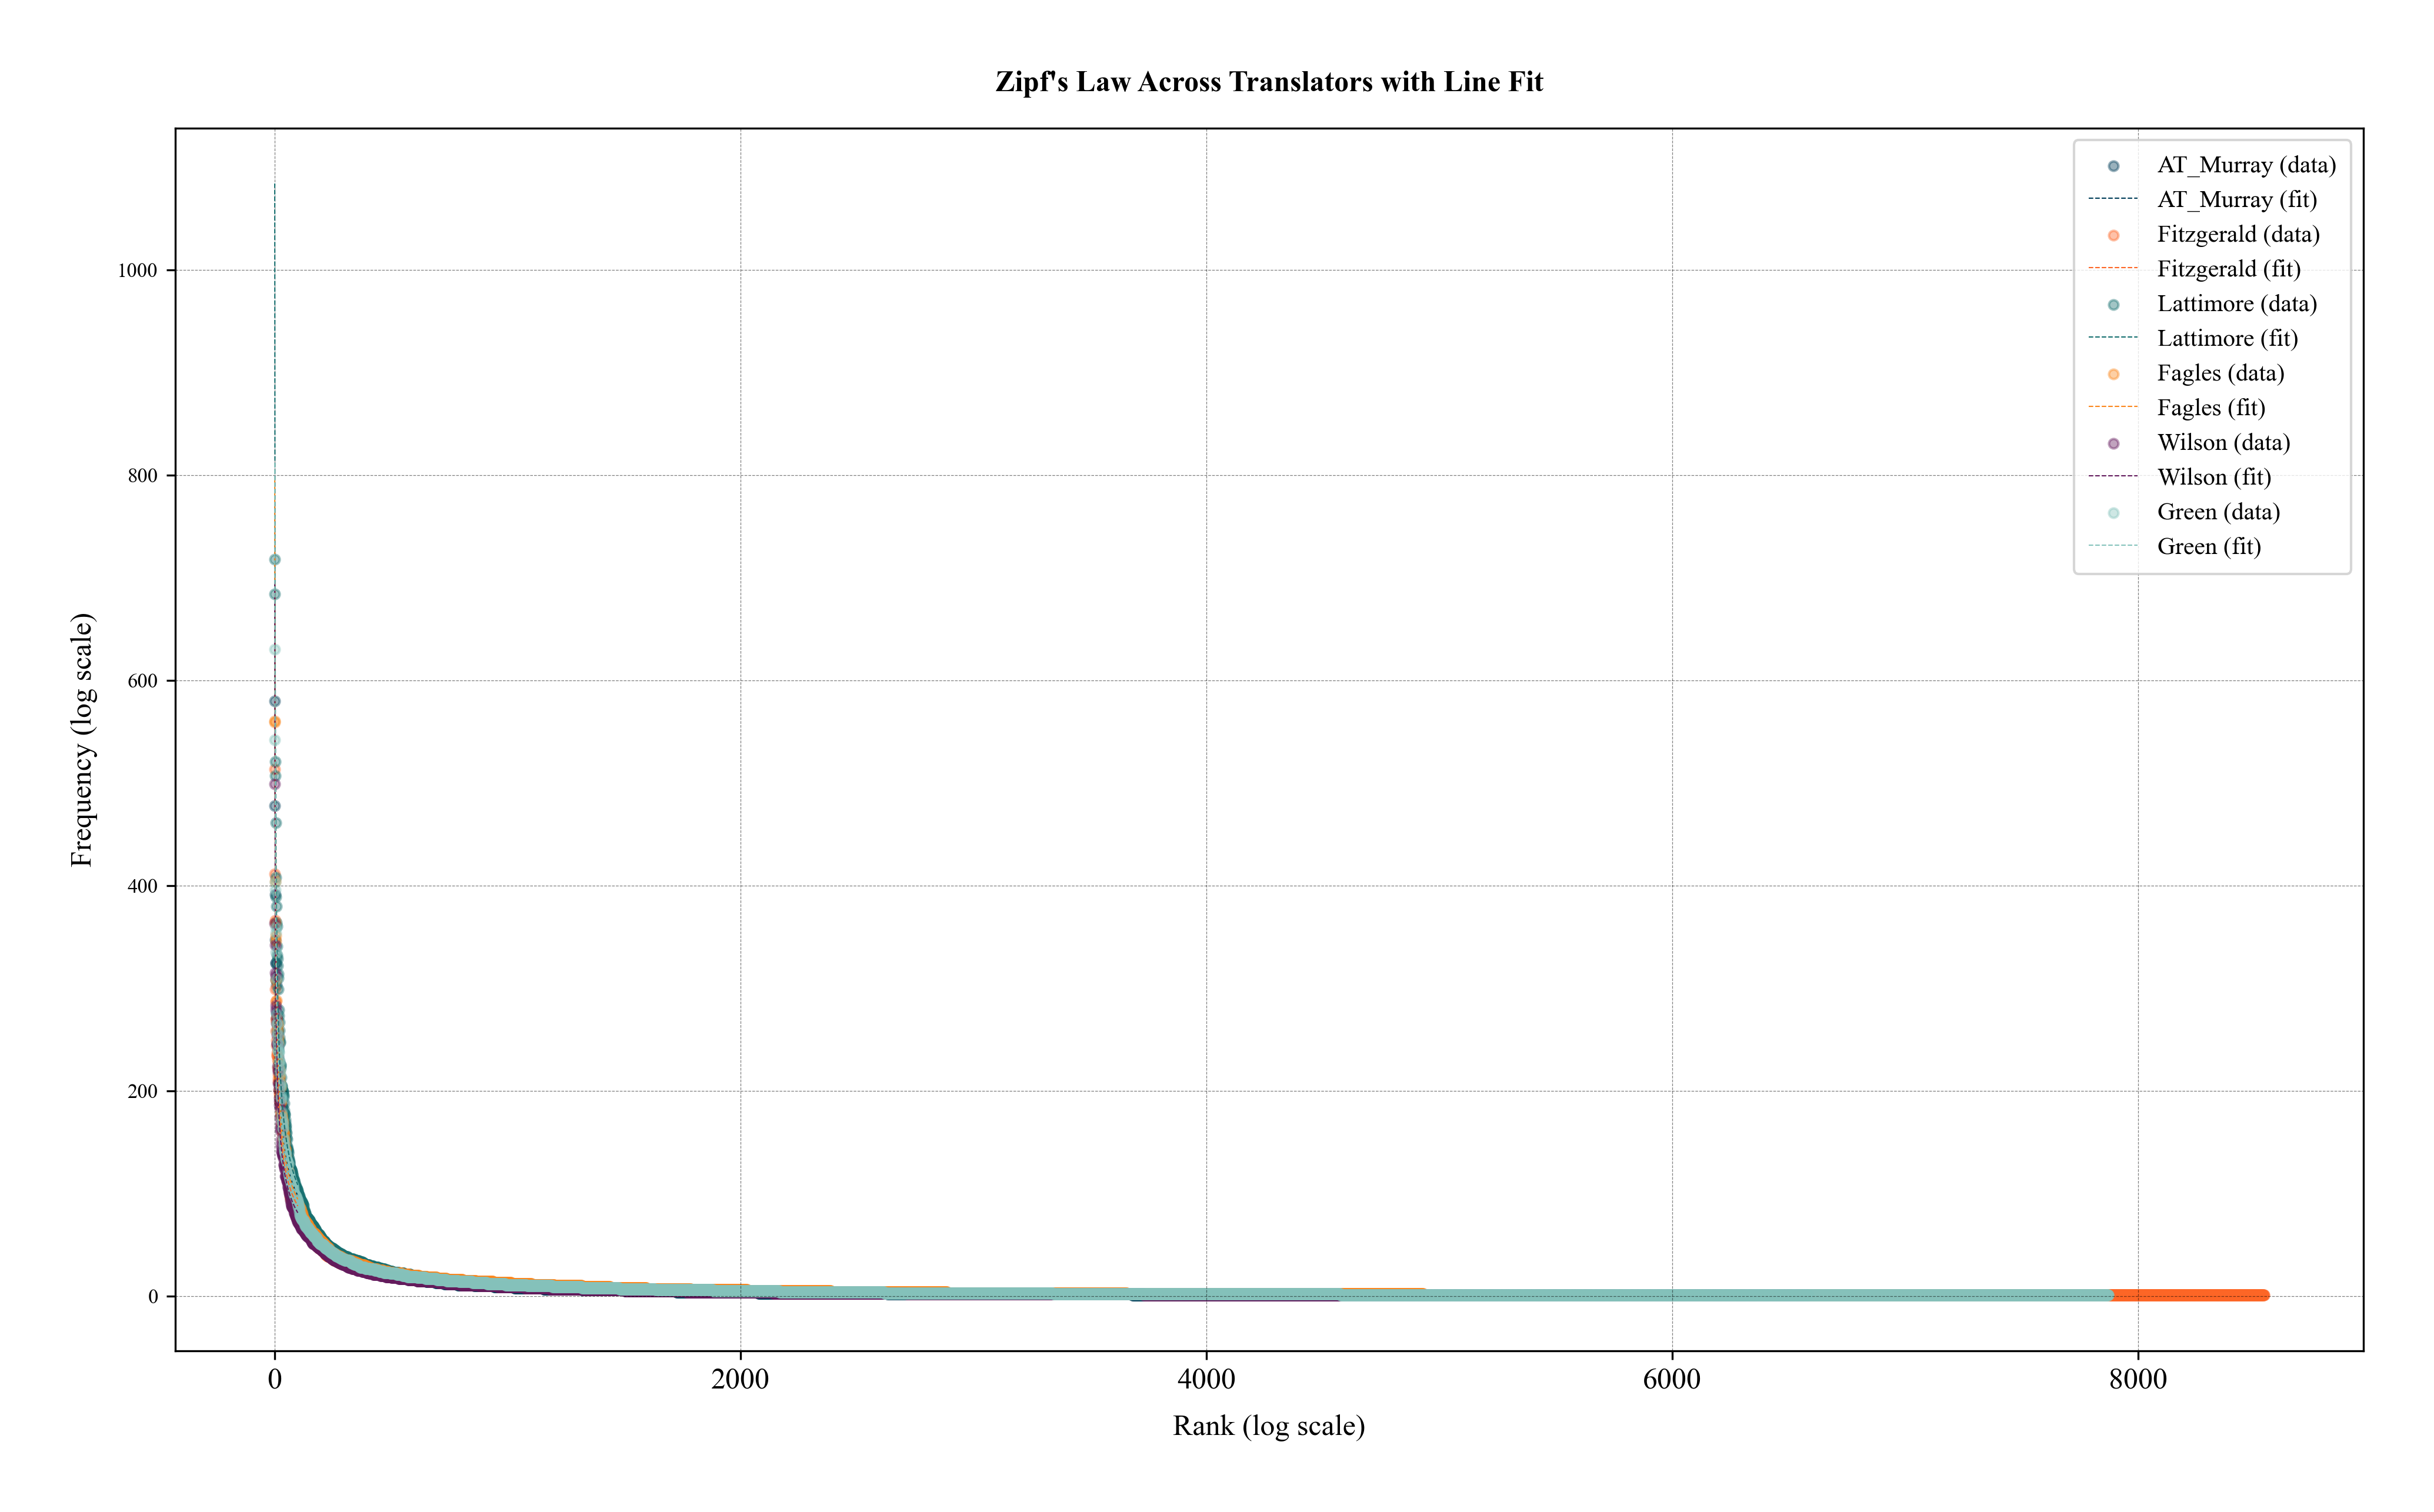

In [11]:
# Step 4: Fit a line to the log-log data

from sklearn.linear_model import LinearRegression

def plot_zipfs_law_with_fit(df_word_freq_rank_dict):
    fig, ax = plt.subplots()  # Create figure and axis

    for translator, df_zipf in df_word_freq_rank_dict.items():
        top_n = 100  # Adjust as needed
        df_zipf_top = df_zipf.head(top_n)

        # Log-transform the rank and frequency for fitting
        x = np.log(df_zipf_top["rank"].values.reshape(-1, 1))
        y = np.log(df_zipf_top["frequency"].values)

        # Fit a linear regression to the log-log data
        model = LinearRegression()
        model.fit(x, y)
        y_pred = model.predict(x)

        # Scatter plot of the actual data
        ax.scatter(df_zipf["rank"], df_zipf["frequency"], label=f"{translator} (data)", alpha=0.4, s=15)

        # Line of best fit
        ax.plot(df_zipf_top["rank"], np.exp(y_pred), label=f"{translator} (fit)", linestyle="--", lw=0.5)

    ax.set_xlabel("Rank (log scale)")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_title("Zipf's Law Across Translators with Line Fit")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", linewidth=0.3)

    return fig  # Return the figure object

fig = plot_zipfs_law_with_fit(df_word_freq_rank_dict)

# Save the figure properly
chroma.save_figure(fig, f"Log-Log-Fit-{nb_id}.png")

In [12]:
#--------------------------------------------------------------
# Zipf's Law Analysis with Linear Regression
#--------------------------------------------------------------
from scipy.stats import linregress

# Create empty lists to store results
slopes = []
r_squared = []
p_values = []
std_errs = []
follows_zipf = []

# Perform linear regression in log-log space for each translator
for translator in translators:
    df_zipf = df_word_freq_rank_dict[translator]
    
    # Log-transform the rank and frequency
    #log_rank = np.log(df_zipf["rank"])
    #log_freq = np.log(df_zipf["frequency"])
    log_rank = np.log(df_zipf["rank"] + 1)  # Add a small constant to avoid log(0)
    log_freq = np.log(df_zipf["frequency"] + 1)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
    
    # Store results
    slopes.append(slope)
    r_squared.append(r_value**2)
    p_values.append(p_value)
    std_errs.append(std_err)
    follows_zipf.append(-1.2 < slope < -0.8)
    
    # Display individual results
    print(f"{translator}: Slope = {slope:}, R² = {r_value**2:}, p-value = {p_value:}")
    
    # Check if slope is close to -1 (Zipf's Law predicts ~ -1)
    if -1.2 < slope < -0.8:
        print(f"{translator}'s translation follows Zipf's Law.")
    else:
        print(f"{translator}'s translation deviates from Zipf's Law.")
    print("-" * 50)

# Create a summary dataframe
results_df = pd.DataFrame({
    'Translator': translators,
    'Slope': slopes,
    'R²': r_squared,
    'p-value': p_values,
    'Std Error': std_errs,
    'Follows Zipf\'s Law': follows_zipf
})

print("\nSummary of Zipf's Law Analysis:")
print(results_df)


AT_Murray: Slope = -0.9542932093576058, R² = 0.9806438935167807, p-value = 0.0
AT_Murray's translation follows Zipf's Law.
--------------------------------------------------
Fitzgerald: Slope = -0.8650585004530146, R² = 0.9770997041606634, p-value = 0.0
Fitzgerald's translation follows Zipf's Law.
--------------------------------------------------
Lattimore: Slope = -1.0027317864449838, R² = 0.9806556264765379, p-value = 0.0
Lattimore's translation follows Zipf's Law.
--------------------------------------------------
Fagles: Slope = -0.9349911474605519, R² = 0.9811054731876746, p-value = 0.0
Fagles's translation follows Zipf's Law.
--------------------------------------------------
Wilson: Slope = -0.9224031857694105, R² = 0.9789056895248922, p-value = 0.0
Wilson's translation follows Zipf's Law.
--------------------------------------------------
Green: Slope = -0.9273243258759374, R² = 0.9808147462839082, p-value = 0.0
Green's translation follows Zipf's Law.
-------------------------

## **Interpreting the results:**

The regression model of Zipf's Law finds an extremely strong correlation between rank and frequency with very low variability in the estimated slope.

1. **Near-Perfect Fit (R² ≈ 0.98)**
    * R² values are extremely high (~0.98), meaning the model explains almost all the variance in the data.
    * A nearly perfect linear relationship in log-log space leads to a very low p-value.

2.	**p-value Interpretation**
    * The p-value so small that it rounds to 0.00: the data strongly follows Zipf’s Law (which predicts a near-linear log-log relationship).

3.	**Standard Error = 0**
    * Because the data perfectly follows Zipf’s Law, all points are nearly collinear in log-log space, leaving no residual error, which leads to a standard error of 0.00.

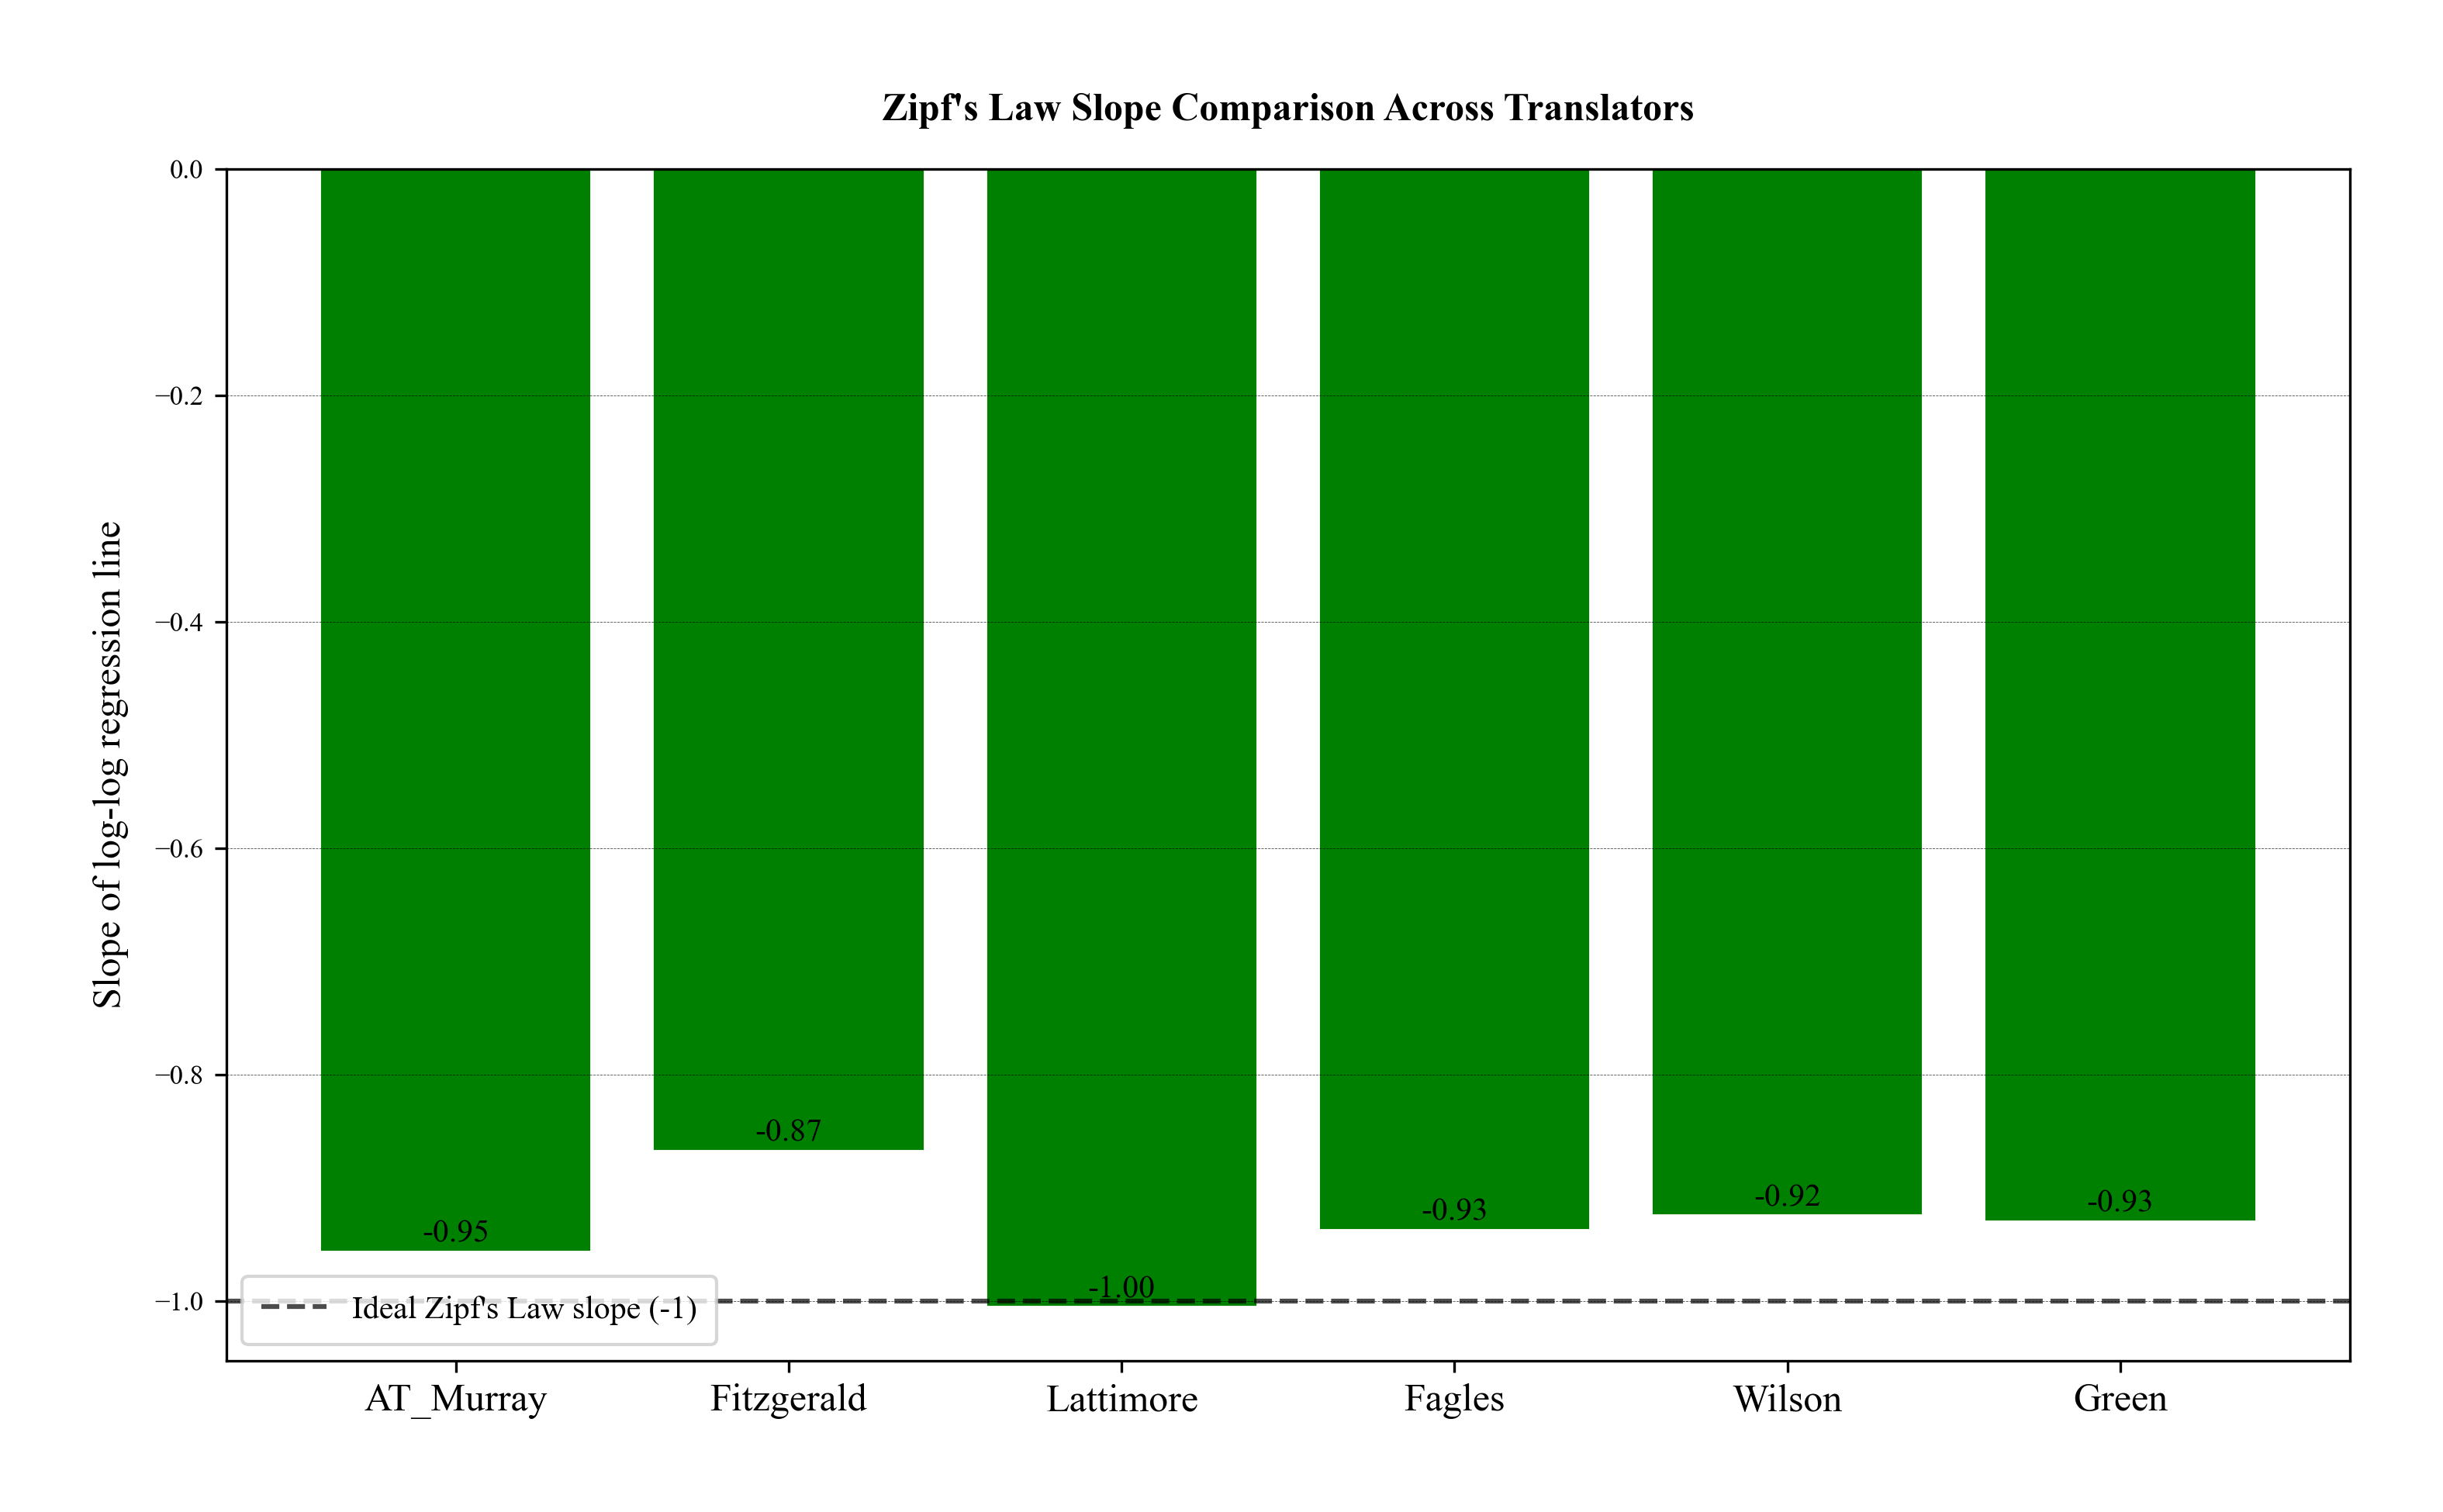

In [13]:
# Bar chart to visualize slopes
plt.figure(figsize=(10, 6))
bars = plt.bar(translators, slopes)

# Color the bars based on whether they follow Zipf's Law
for i, follows in enumerate(follows_zipf):
    bars[i].set_color('green' if follows else 'red')

# Add a horizontal line at -1 (ideal Zipf's Law slope)
plt.axhline(y=-1, color='black', linestyle='--', alpha=0.7, 
            label="Ideal Zipf's Law slope (-1)")

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{slopes[i]:.2f}',
            ha='center', va='bottom' if height < 0 else 'top', 
            rotation=0)

plt.title("Zipf's Law Slope Comparison Across Translators")
plt.ylabel("Slope of log-log regression line")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(output_path_plots + f"Comparison-{nb_id}.png")
plt.show()

In [14]:
# Statistical comparison of slopes (using confidence intervals)
print("\nStatistical comparison of slopes:")
for i in range(len(translators)):
    for j in range(i+1, len(translators)):
        # Calculate standard error of the difference between slopes
        se_diff = np.sqrt(std_errs[i]**2 + std_errs[j]**2)
        
        # Calculate t-statistic
        t_stat = (slopes[i] - slopes[j]) / se_diff
        
        # Calculate degrees of freedom (approximation)
        d_freedom = len(df_word_freq_rank_dict[translators[i]]["rank"]) + len(df_word_freq_rank_dict[translators[j]]["rank"]) - 4
        
        # Calculate p-value
        from scipy.stats import t
        p_val = 2 * (1 - t.cdf(abs(t_stat), d_freedom))
        
        print(f"{translators[i]} vs {translators[j]}: Slope diff = {slopes[i]-slopes[j]:.3f}, p = {p_val:.4f}")
        if p_val < 0.05:
            print("   -> Statistically significant difference in slopes")
        else:
            print("   -> No statistically significant difference in slopes")


Statistical comparison of slopes:
AT_Murray vs Fitzgerald: Slope diff = -0.089, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Lattimore: Slope diff = 0.048, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Fagles: Slope diff = -0.019, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Wilson: Slope diff = -0.032, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Green: Slope diff = -0.027, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Lattimore: Slope diff = 0.138, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Fagles: Slope diff = 0.070, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Wilson: Slope diff = 0.057, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Green: Slope diff = 0.062, p = 0.0000
   -> Statistically significant difference in slopes
Latt

One-Way ANOVA (Single Test for All Translators)

The ANOVA test is used when you want to compare the means of more than two groups—in this case, the slopes of the different translators. This will tell you if there are any significant differences between the slopes across all translators.


In [15]:
# Slopes for each translator
slopes = results_df["Slope"]
type(slopes)

pandas.core.series.Series

In [16]:
slopes = dict(zip(results_df['Translator'], results_df['Slope']))
slopes

{'AT_Murray': -0.9542932093576058,
 'Fitzgerald': -0.8650585004530146,
 'Lattimore': -1.0027317864449838,
 'Fagles': -0.9349911474605519,
 'Wilson': -0.9224031857694105,
 'Green': -0.9273243258759374}

t-test pairwise comparison:

In [17]:
#-----------------------------------------------------------------
# Perform pairwise t-tests for differences in slopes
#-----------------------------------------------------------------

from scipy.stats import ttest_ind

# Convert dictionary to a list of slopes
slope_values = list(slopes.values())

# Perform pairwise t-tests for differences in slopes
for i in range(len(slope_values)):
    for j in range(i+1, len(slope_values)):
        translator_1 = list(slopes.keys())[i]
        translator_2 = list(slopes.keys())[j]
        
        # Compare slopes for translator_1 and translator_2
        t_stat, p_value = ttest_ind([slope_values[i]], [slope_values[j]])

        # Interpretation
        print(f"Comparison: {translator_1} vs {translator_2}")
        print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")
        
        if p_value < 0.05:
            print(f"  -> There is a significant difference in slopes between {translator_1} and {translator_2}.")
        else:
            print(f"  -> No significant difference in slopes between {translator_1} and {translator_2}.")
        print("-" * 50)

Comparison: AT_Murray vs Fitzgerald
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Fitzgerald.
--------------------------------------------------
Comparison: AT_Murray vs Lattimore
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Lattimore.
--------------------------------------------------
Comparison: AT_Murray vs Fagles
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Fagles.
--------------------------------------------------
Comparison: AT_Murray vs Wilson
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Wilson.
--------------------------------------------------
Comparison: AT_Murray vs Green
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Green.
--------------------------------------------------
Comparison: Fitzgerald vs Lattimore
T-statistic: nan, P-value: 

ANOVA F-statistic: nan, P-value: nan
No statistically significant difference in Zipf's Law slopes across translators.


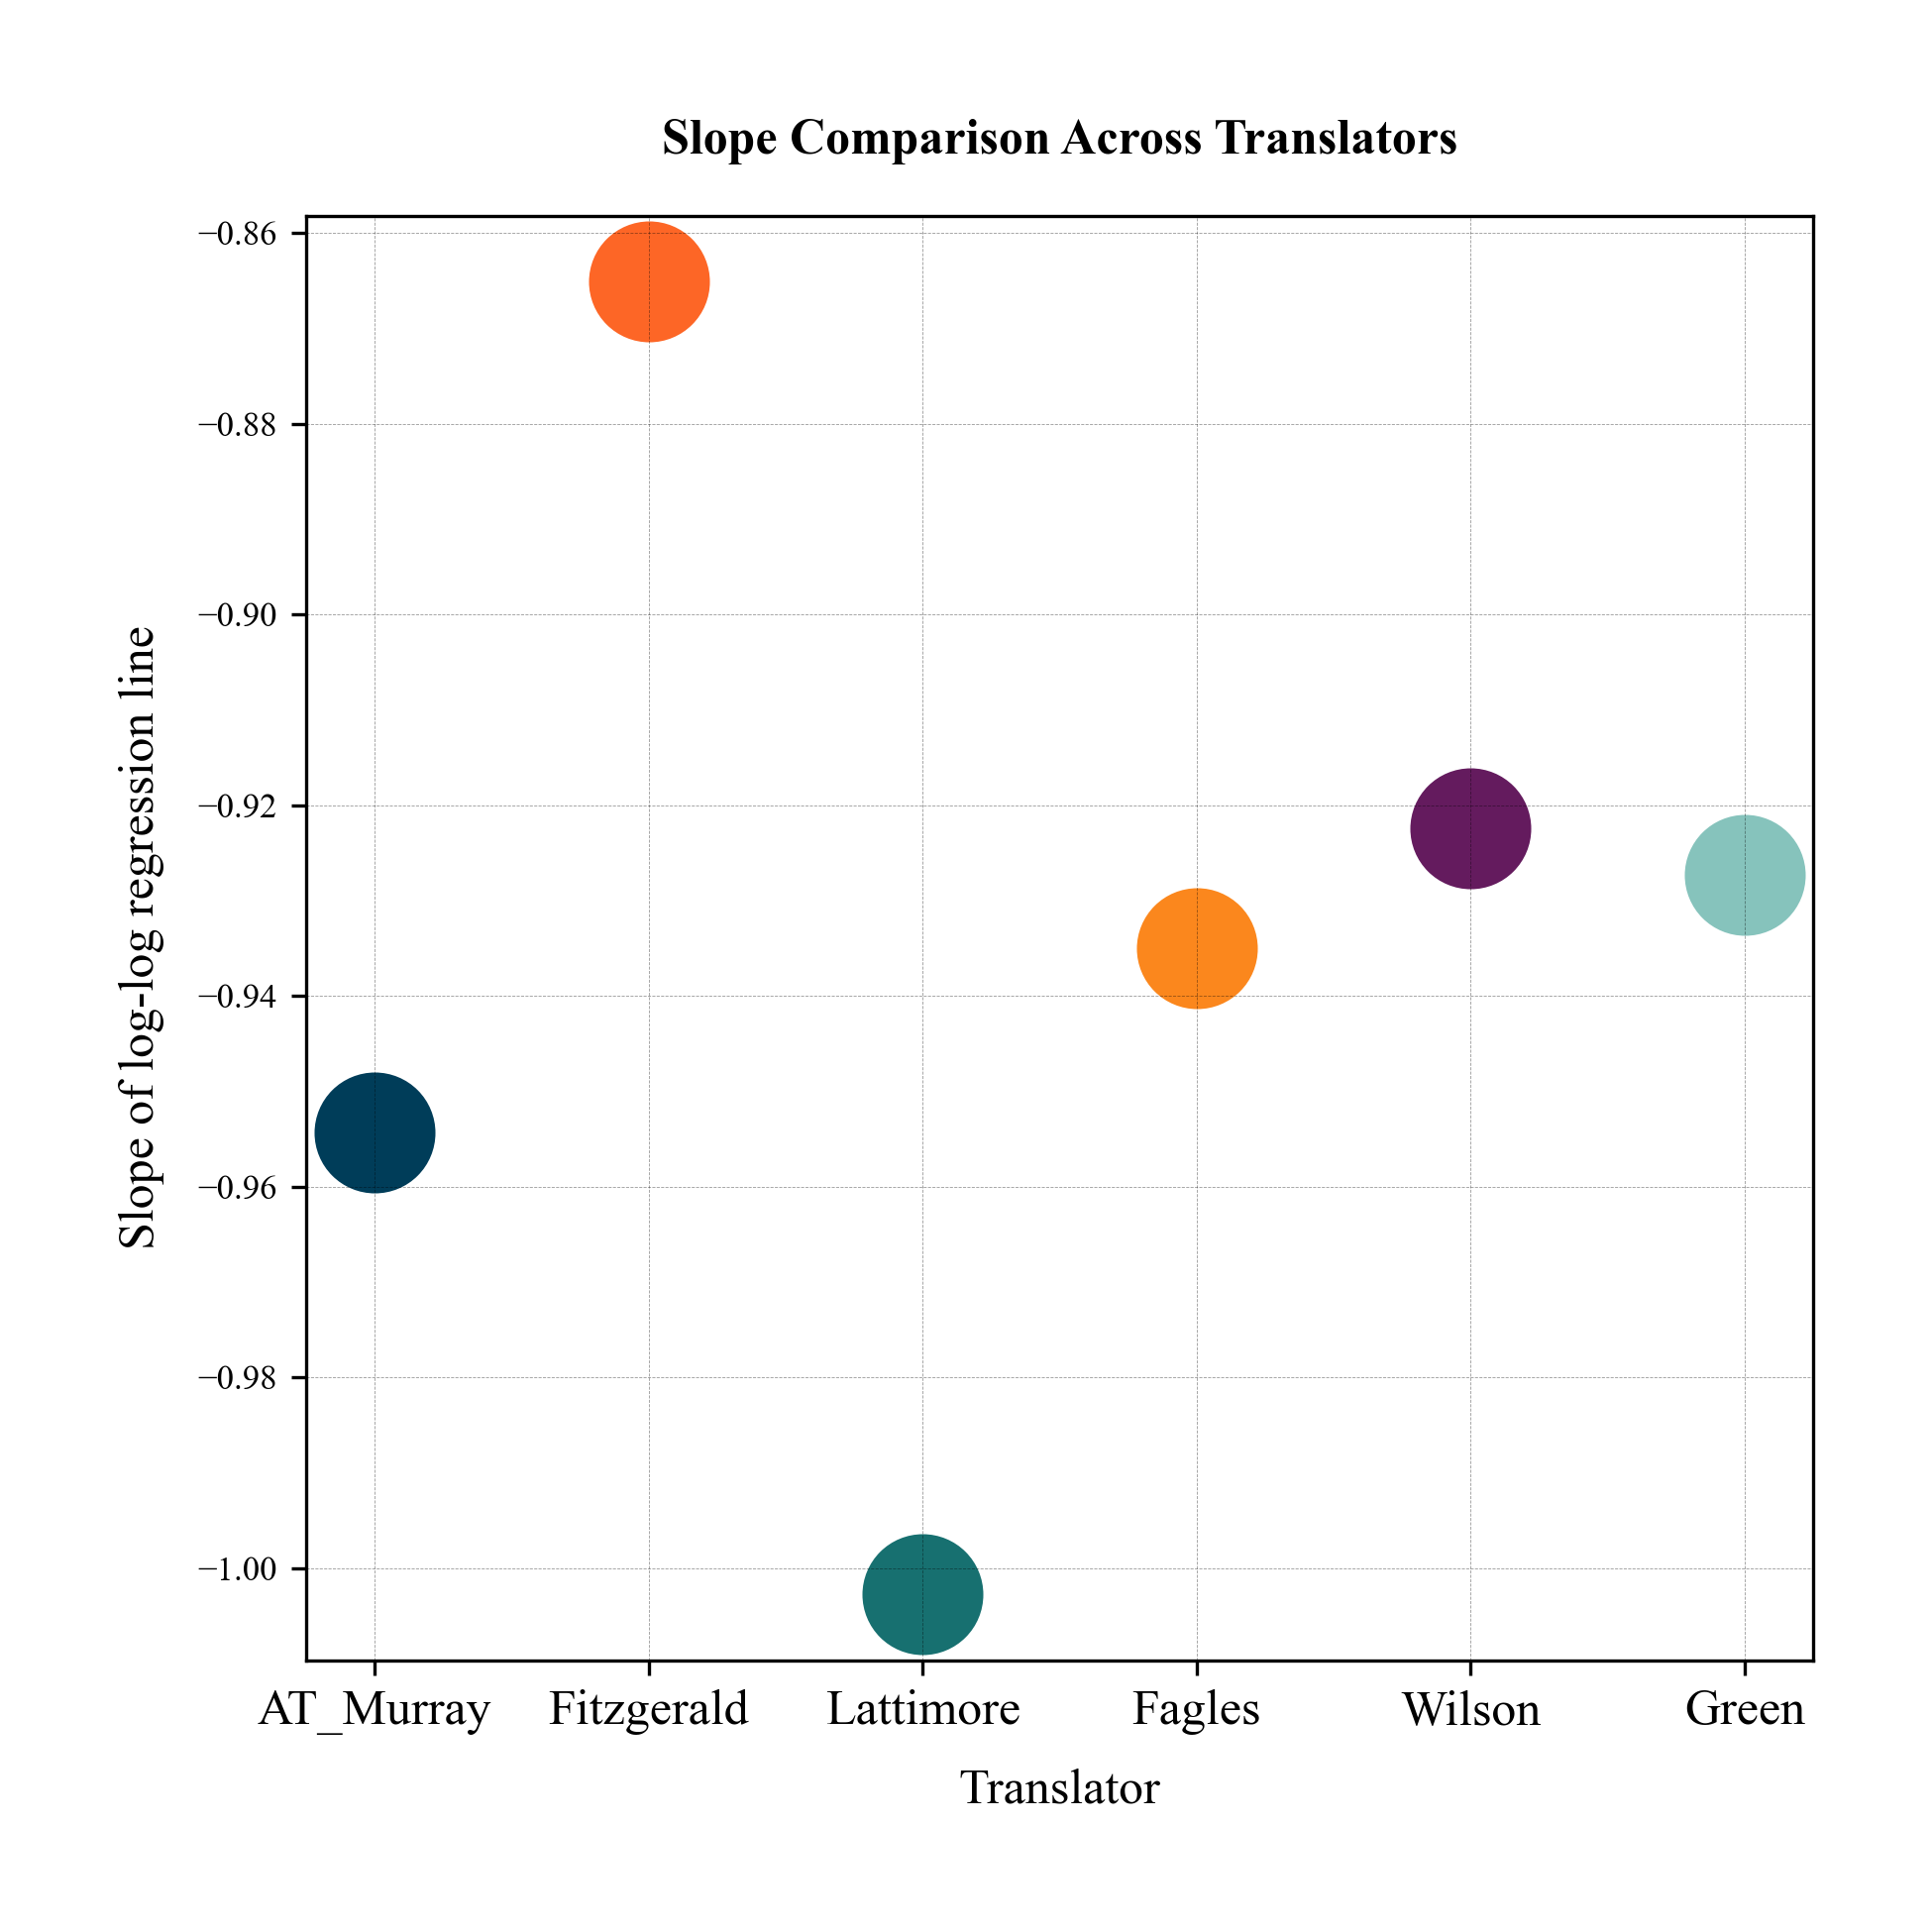

In [18]:
# ----------------------------------------------------------------------
# Zipf's Law Slope Comparison
# ----------------------------------------------------------------------

from scipy.stats import f_oneway

slopes_by_translator = {translator: [] for translator in df['translator'].unique()}

for index, row in df.iterrows():
    translator = row['translator']
    book_num = row['book_num']  
    df_zipf = df_word_freq_rank_dict[translator]
    
    if 'book_num' not in df_zipf.columns:
        df_zipf['book_num'] = [book_num] * len(df_zipf)
    
    df_book = df_zipf[df_zipf['book_num'] == book_num]
    
    if not df_book.empty:
        log_rank = np.log(df_book["rank"] + 1)  # Add 1 to avoid log(0)
        log_freq = np.log(df_book["frequency"] + 1)  # Add 1 to avoid log(0)
        
        # Perform linear regression on the log-log space
        slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
        slopes_by_translator[translator].append(slope)

slope_groups = [slopes_by_translator[translator] for translator in slopes_by_translator]
f_stat, p_value = f_oneway(*slope_groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, P-value: {p_value:.5f}")
if p_value < 0.05:
    print("There is a statistically significant difference in Zipf's Law slopes across translators.")
else:
    print("No statistically significant difference in Zipf's Law slopes across translators.")

plt.figure(figsize=(6, 6))
for translator, slopes in slopes_by_translator.items():
    plt.scatter([translator] * len(slopes), slopes, label=translator, s=800)

plt.title("Slope Comparison Across Translators")
plt.ylabel("Slope of log-log regression line")
plt.xlabel("Translator")
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks()
plt.tight_layout()
plt.savefig(output_path_plots + f"Translator_Slope_Box-{nb_id}.png")
plt.show()            

In [19]:
# ----------------------------------------------------------------------
# Zipf's Law Analysis
# ----------------------------------------------------------------------
# Create a function to calculate Zipf's law for each book and author
def calculate_zipf(row):
    # Tokenize the 'text' column (assuming words are space-separated)
    words = row['tokens']  # Use the list of tokens directly
    
    # Calculate frequency of each word
    word_freq = pd.Series(words).value_counts()
    
    # Rank words based on frequency (most frequent gets rank 1)
    word_freq = word_freq.sort_values(ascending=False)
    
    # Rank is the index of the sorted values (this is the Zipf rank)
    ranks = np.log(np.arange(1, len(word_freq) + 1))  # Zipf's Law ranks, log scale
    
    # Compute Zipf's law score: Rank vs. Frequency relationship
    log_freq = np.log(word_freq.values + 1)  # Log-transform frequency (to avoid log(0))
    log_rank = np.log(ranks + 1)  # Log-transform rank (to avoid log(0))
    
    # You can use linear regression or other methods to compute the Zipf slope, or just save the rank values.
    # For simplicity, I will return the Zipf rank.
    
    return log_rank, log_freq  # You can modify what you want to return (rank, frequency, slope, etc.)

# Apply this function to each row in the df
df['zipf'] = df.apply(calculate_zipf, axis=1)

# The result will be a tuple, you may want to expand it into two separate columns (for rank and frequency):
df[['zipf_rank', 'zipf_freq']] = pd.DataFrame(df['zipf'].tolist(), index=df.index)

# If you want to combine both values into a single "zipf" column, you can do that as well:
df['zipf'] = df['zipf_rank'] - df['zipf_freq']  # or any other combination you need

# View the result
print(df[['zipf', 'zipf_rank', 'zipf_freq']].head())

  zipf                                                                                                                                                                                                     zipf_rank                                                                                                                                                                                                zipf_freq                                                                                                                                                                                               
0  [-3.258096538021482, -2.4691432394149464, -2.2031626677914247, -2.0746972929744962, -1.9312369189753404, -1.8636997266971136, -1.8099539396231767, -1.647840459330745, -1.5457670872182097, -1.51334...  [0.0, 0.5265890341390446, 0.7412763113750154, 0.8697416861919439, 0.959134838920824, 1.026672031199051, 1.0804178182729878, 1.1247482629090362, 1.1622831138840004, 1.1947055233182955, 1.22315

In [20]:
len(df['zipf'][0])

881

In [21]:
len(set(df['tokens'][0]))

881

In [22]:
# ----------------------------------------------------------------------
# Bootstrapping the slope
# ----------------------------------------------------------------------
from scipy.stats import linregress

# Assuming you already have your DataFrame (df) and the 'zipf' columns are calculated

# Define a function for bootstrapping the slope
def bootstrap_slope(df, n_bootstrap=1000):
    slopes_bootstrap = []
    
    for _ in range(n_bootstrap):
        # Sample data with replacement
        bootstrap_sample = df.sample(n=len(df), replace=True)
        
        # Get the log-transformed rank and frequency
        log_rank = np.log(bootstrap_sample['rank'] + 1)  # Avoid log(0)
        log_freq = np.log(bootstrap_sample['frequency'] + 1)
        
        # Perform linear regression on the bootstrap sample
        slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
        
        # Store the slope
        slopes_bootstrap.append(slope)
    
    # Convert to a numpy array for easier analysis
    slopes_bootstrap = np.array(slopes_bootstrap)
    
    # Calculate 95% confidence intervals
    lower_bound = np.percentile(slopes_bootstrap, 2.5)
    upper_bound = np.percentile(slopes_bootstrap, 97.5)
    
    # Return the distribution of slopes and the confidence intervals
    return slopes_bootstrap, lower_bound, upper_bound

# Now, let's apply the bootstrap for each author
bootstrap_results = {}
for translator in translators:
    df_translator = df_word_freq_rank_dict[translator]
    
    # Run the bootstrap procedure
    slopes_bootstrap, lower_bound, upper_bound = bootstrap_slope(df_translator, n_bootstrap=1000)
    
    # Store the results
    bootstrap_results[translator] = {
        'bootstrap_slopes': slopes_bootstrap,
        '95% CI Lower Bound': lower_bound,
        '95% CI Upper Bound': upper_bound
    }

# Print results
for translator, result in bootstrap_results.items():
    print(f"{translator}:")
    print(f"  95% CI for slope: ({result['95% CI Lower Bound']:.4f}, {result['95% CI Upper Bound']:.4f})")
    print(f"  Mean slope: {np.mean(result['bootstrap_slopes']):.4f}")
    print("-" * 50)

AT_Murray:
  95% CI for slope: (-0.9638, -0.9441)
  Mean slope: -0.9543
--------------------------------------------------
Fitzgerald:
  95% CI for slope: (-0.8705, -0.8584)
  Mean slope: -0.8649
--------------------------------------------------
Lattimore:
  95% CI for slope: (-1.0138, -0.9922)
  Mean slope: -1.0030
--------------------------------------------------
Fagles:
  95% CI for slope: (-0.9436, -0.9256)
  Mean slope: -0.9351
--------------------------------------------------
Wilson:
  95% CI for slope: (-0.9312, -0.9124)
  Mean slope: -0.9223
--------------------------------------------------
Green:
  95% CI for slope: (-0.9347, -0.9195)
  Mean slope: -0.9274
--------------------------------------------------


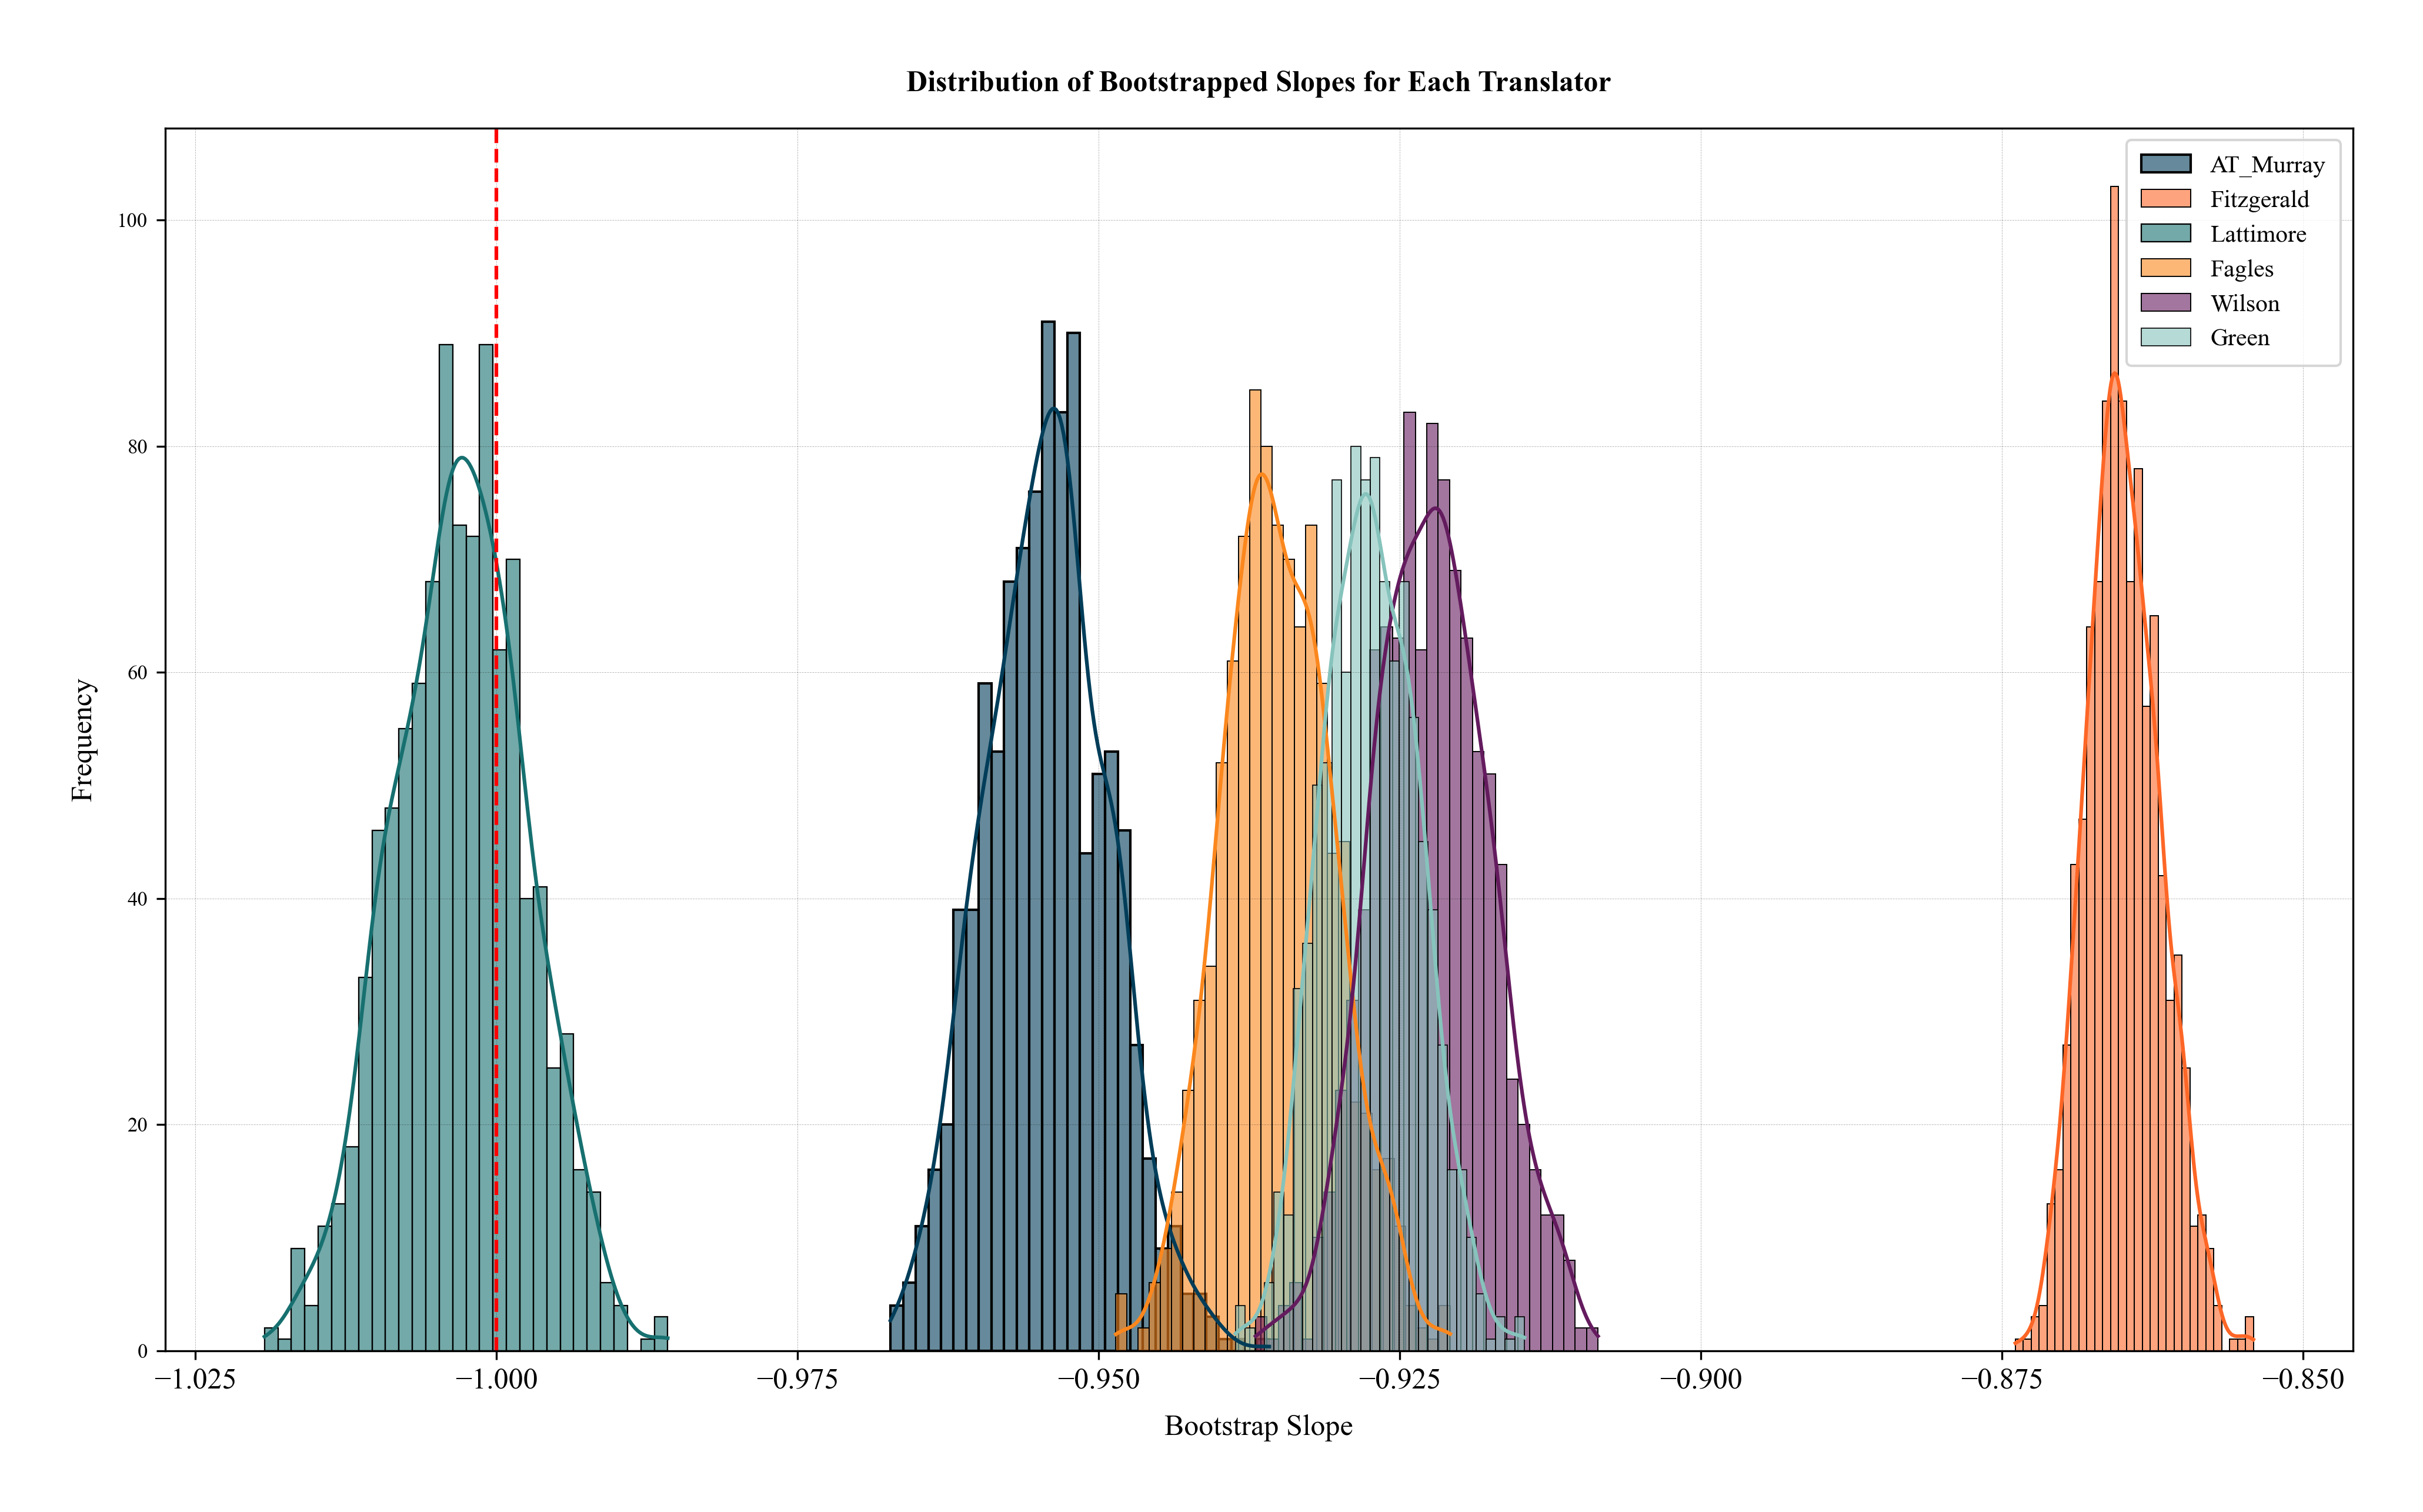

In [23]:
# Bootstrap distribution plots
plt.figure()

# Plot bootstrap distributions for each translator
for translator, result in bootstrap_results.items():
    sns.histplot(result['bootstrap_slopes'], bins=30, 
                 kde=True, label=translator, alpha=0.6)

# Formatting
plt.xlabel("Bootstrap Slope")
plt.ylabel("Frequency")
plt.title("Distribution of Bootstrapped Slopes for Each Translator")
plt.legend()
plt.axvline(x=-1, color='red', linestyle='--', 
            label="Ideal Zipf's Law slope (-1)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig(output_path_plots + f"Bootstrapped_Slopes-{nb_id}.png", dpi=400)
plt.show()

In [24]:
# ----------------------------------------------------------------------
# Confidence Intervals
# ----------------------------------------------------------------------

ci_df = pd.DataFrame({
    'Translator': list(bootstrap_results.keys()),
    'Mean Slope': [np.mean(res['bootstrap_slopes']) for res in bootstrap_results.values()],
    '95% CI Lower Bound': [res['95% CI Lower Bound'] for res in bootstrap_results.values()],
    '95% CI Upper Bound': [res['95% CI Upper Bound'] for res in bootstrap_results.values()]
})

# Display the results
print("\nBootstrap Confidence Intervals for Slopes:")
print(ci_df)


Bootstrap Confidence Intervals for Slopes:
  Translator   Mean Slope  95% CI Lower Bound  95% CI Upper Bound
0   AT_Murray -0.95       -0.96               -0.94              
1  Fitzgerald -0.86       -0.87               -0.86              
2   Lattimore -1.00       -1.01               -0.99              
3      Fagles -0.94       -0.94               -0.93              
4      Wilson -0.92       -0.93               -0.91              
5       Green -0.93       -0.93               -0.92              
